# 03: Anatomy of crypto crashes

Three case studies, picked because they're different in character:

| Event | Why it's interesting |
|---|---|
| **COVID, Mar 2020** | A pure exogenous shock. Crypto behaved as a risk asset, not "digital gold". |
| **Luna / UST, May 2022** | An endogenous implosion. One protocol's design failure became a contagion. |
| **FTX, Nov 2022** | An institutional failure. No protocol broke. Trust did. |

For each one I want the same picture: who moved first, how big the drawdowns were, and how long it took the survivors to recover.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import utils as U

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
prices = U.load_panel()
rets = U.log_returns(prices)

# A wider window than the event itself, so we get the run-up and recovery too.
windows = {
    'COVID': ('2020-01-15', '2020-06-30'),
    'Luna':  ('2022-04-01', '2022-08-31'),
    'FTX':   ('2022-10-15', '2023-02-28'),
}

## Setup: a small helper for event windows

In [3]:
def window(df, name):
    s, e = windows[name]
    return df.loc[s:e].dropna(how='all', axis=1)

def rebased(df, anchor_date):
    """Set anchor_date to 100 for every series and propagate from there."""
    if isinstance(anchor_date, str):
        anchor_date = pd.Timestamp(anchor_date)
    # nearest trading day at or after anchor
    anchor = df.index[df.index >= anchor_date][0]
    return df.div(df.loc[anchor]).mul(100)

## COVID: when crypto failed as a "safe haven"

Bitcoin maximalists had been pitching BTC as digital gold since at least 2017. March 2020 was the first real test.

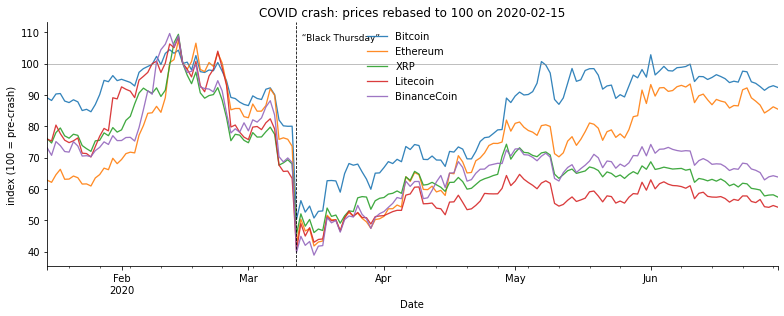

In [4]:
covid = window(prices, 'COVID')
shown = [c for c in ['Bitcoin', 'Ethereum', 'XRP', 'Litecoin', 'BinanceCoin'] if c in covid.columns]
r = rebased(covid[shown], '2020-02-15')

fig, ax = plt.subplots(figsize=(11, 4.5))
r.plot(ax=ax, lw=1.3, alpha=0.9)
ax.axvline(pd.Timestamp('2020-03-12'), color='black', ls='--', lw=0.8)
ax.text(pd.Timestamp('2020-03-12'), ax.get_ylim()[1] * 0.95, '  \u201cBlack Thursday\u201d', fontsize=9)
ax.axhline(100, color='gray', lw=0.5)
ax.set_title('COVID crash: prices rebased to 100 on 2020-02-15')
ax.set_ylabel('index (100 = pre-crash)')
ax.legend(frameon=False)
plt.tight_layout()

In [5]:
# Worst single-day return per coin during the window
rcovid = U.log_returns(covid).dropna(axis=1, how='all')   # drop coins that didn't exist yet
worst = rcovid.min().dropna().sort_values()
worst_day = rcovid.idxmin()

covid_summary = pd.DataFrame({
    'worst_day_return': worst,
    'date': [worst_day[c].strftime('%Y-%m-%d') if pd.notna(worst_day[c]) else 'n/a'
             for c in worst.index],
})
covid_summary.round(3)

,worst_day_return,date
ChainLink,-0.615,2020-03-12
Ethereum,-0.551,2020-03-12
BinanceCoin,-0.543,2020-03-12
Cardano,-0.504,2020-03-12
Bitcoin,-0.465,2020-03-12
Litecoin,-0.449,2020-03-12
XRP,-0.399,2020-03-12
Dogecoin,-0.351,2020-03-12
Solana,-0.202,2020-04-11
Tether,-0.053,2020-03-13


All concentrated on **March 12, 2020**. The entire panel printed its worst day on the same day. That's the diversification problem in one line: when the market truly panics, there's no asset to hide behind. BTC lost ~37% in 24h alongside everything else.

## Luna / UST: a chain reaction, not a market move

Luna was different. UST de-pegged on May 9th, and Luna's price collapsed mechanically through the design of the protocol. Every UST holder who tried to redeem minted more Luna, diluting existing holders into oblivion.

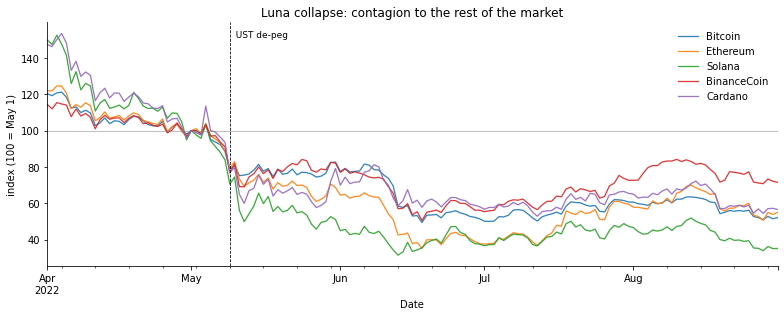

In [6]:
luna = window(prices, 'Luna')
shown = [c for c in ['Bitcoin', 'Ethereum', 'Solana', 'BinanceCoin', 'Cardano'] if c in luna.columns]
r = rebased(luna[shown], '2022-05-01')

fig, ax = plt.subplots(figsize=(11, 4.5))
r.plot(ax=ax, lw=1.3, alpha=0.9)
ax.axvline(pd.Timestamp('2022-05-09'), color='black', ls='--', lw=0.8)
ax.text(pd.Timestamp('2022-05-09'), ax.get_ylim()[1] * 0.95, '  UST de-peg', fontsize=9)
ax.axhline(100, color='gray', lw=0.5)
ax.set_title('Luna collapse: contagion to the rest of the market')
ax.set_ylabel('index (100 = May 1)')
ax.legend(frameon=False)
plt.tight_layout()

Two things stand out:
1. The contagion to BTC/ETH was real but not catastrophic. They lost ~25 to 30% over the window. Painful but survivable.
2. There's a clear lead-lag. The steep drop starts a day or two before the official "de-peg" date, as the market sensed what was coming.

The yfinance data doesn't include Luna itself (it's a small altcoin that lost 99.99% of its value), so what we can measure here is the contagion to everything else. That's actually the more useful question for a portfolio. What happened to the survivors?

## FTX: when a custodian goes

FTX wasn't a protocol failure. The token system worked as designed. What broke was trust in centralized intermediaries, and that pulled prices down across the board.

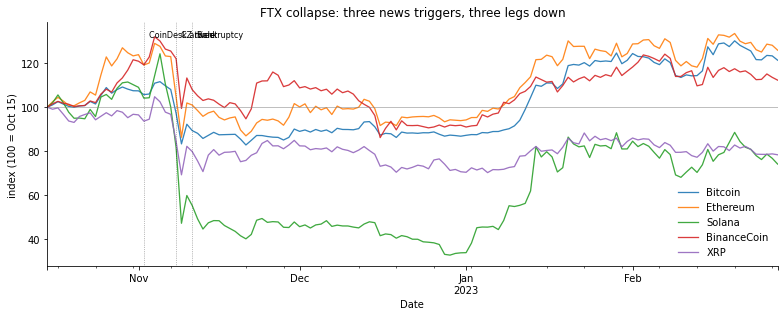

In [7]:
ftx = window(prices, 'FTX')
shown = [c for c in ['Bitcoin', 'Ethereum', 'Solana', 'BinanceCoin', 'XRP'] if c in ftx.columns]
r = rebased(ftx[shown], '2022-10-15')

fig, ax = plt.subplots(figsize=(11, 4.5))
r.plot(ax=ax, lw=1.3, alpha=0.9)
for d, label in [('2022-11-02', 'CoinDesk article'), ('2022-11-08', 'CZ tweet'), ('2022-11-11', 'Bankruptcy')]:
    ax.axvline(pd.Timestamp(d), color='black', ls=':', lw=0.7, alpha=0.5)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1] * 0.95, f'  {label}', fontsize=8, rotation=0)
ax.axhline(100, color='gray', lw=0.5)
ax.set_title('FTX collapse: three news triggers, three legs down')
ax.set_ylabel('index (100 = Oct 15)')
ax.legend(frameon=False)
plt.tight_layout()

Solana was the standout loser here. It had heavy FTX/Alameda ties, both as an ecosystem investor and via locked tokens, so it got punished proportionally harder than BTC or ETH. Useful demonstration that contagion has structure: assets closer to the failure point fell more, even controlling for general beta.

## Recovery: how long does it take to make a new high?

In [8]:
def days_to_recover(series, crash_start, crash_end):
    """For each coin: how many days from the crash trough to a new all-time high
    (within the dataset). Returns NaN if there's no usable data on either side."""
    series = series.dropna()
    pre = series.loc[:crash_start]
    if pre.empty:
        return np.nan          # coin didn't exist before the crash
    crash = series.loc[crash_start:crash_end]
    if crash.empty:
        return np.nan
    pre_peak = pre.max()
    trough_idx = crash.idxmin()
    after = series.loc[trough_idx:]
    above = after[after >= pre_peak]
    return (above.index[0] - trough_idx).days if len(above) else np.nan

rec = {}
for name, (s, e) in windows.items():
    rec[name] = {c: days_to_recover(prices[c], s, e) for c in prices.columns}
rec = pd.DataFrame(rec)
rec.round(0)

,COVID,Luna,FTX
Bitcoin,263.0,625.0,469.0
Ethereum,323.0,1161.0,1017.0
BinanceCoin,288.0,717.0,536.0
Cardano,345.0,NaN,NaN
Solana,NaN,950.0,751.0
XRP,1953.0,1125.0,981.0
Polkadot,NaN,NaN,NaN
Dogecoin,322.0,NaN,NaN
Litecoin,423.0,NaN,NaN
ChainLink,33.0,NaN,NaN


Two things to note:
- NaN means the coin never reclaimed its pre-crash peak within the dataset's window. That's a real result, not a missing value. For some coins (looking at you, XRP) the 2017-2018 peak was never seen again, so a 2022 drawdown is measured against a much lower reference.
- Recovery times for the survivors of FTX/Luna were on the order of 12 to 18 months, which matches the broader 2023 recovery narrative.

## What this section is really for

When I'm walking someone through this project in an interview, the question I'm trying to answer isn't "when did crypto crash". It's how crypto crashes:

- Exogenous shocks (COVID): everything dumps simultaneously, correlations go to 1, no place to hide.
- Protocol failures (Luna): contagion concentrated in nearest-neighbours, BTC and ETH less affected.
- Institutional failures (FTX): step-function drops triggered by news events, magnitude proportional to exposure to the failing entity.

That structural difference is the kind of insight a backtest alone won't tell you.